# TP03 — Classification d'images (CIFAR-10) — **TensorFlow / Keras**

**M2 DMIA — Deep Learning — Session 3**

Objectif : entraîner un **CNN** pour classer des images couleur CIFAR-10 (10 classes) et atteindre **~70–78 %** d'accuracy.

On suit le **pipeline DL** standard, adapté aux images :
1. Charger → 2. Prétraiter (garder la forme 32×32×3 !) → 3. Définir le CNN → 4. Perte + optimiseur → 5. Entraîner (+ data augmentation) → 6. Évaluer → 7. Analyser.

> 💡 Recommandé : exécuter sur **Google Colab** avec **GPU** (Exécution → Modifier le type d'exécution → GPU).

## 0. Imports et reproductibilité

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproductibilite (la meme graine -> les memes resultats)
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version :', tf.__version__)

TensorFlow version : 2.21.0


## 1. Charger les données

CIFAR-10 est intégré à Keras : 50 000 images d'entraînement et 10 000 de test, en couleur 32×32×3, réparties en 10 classes.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Les labels sont de forme (N, 1) -> on les aplatit en (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ['avion', 'auto', 'oiseau', 'chat', 'cerf',
               'chien', 'grenouille', 'cheval', 'bateau', 'camion']

print('x_train :', x_train.shape, '| y_train :', y_train.shape)
print('x_test  :', x_test.shape,  '| y_test  :', y_test.shape)
print('valeurs des pixels : min =', x_train.min(), ', max =', x_train.max())

x_train : (50000, 32, 32, 3) | y_train : (50000,)
x_test  : (10000, 32, 32, 3) | y_test  : (10000,)
valeurs des pixels : min = 0 , max = 255


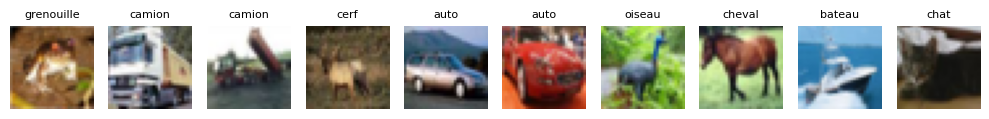

In [3]:
# Visualisons quelques exemples
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]], fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Prétraiter

- **Normaliser** les pixels de [0, 255] vers [0, 1].
- **Important** : on **ne** aplatit **pas** les images ! Le CNN a besoin de la forme spatiale 32×32×3.
- On garde les labels en entiers (0–9) et on utilisera `sparse_categorical_crossentropy`.

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print('Apres normalisation : min =', x_train.min(), ', max =', x_train.max())
print('Forme conservee :', x_train.shape[1:], '(on garde 32x32x3)')

Apres normalisation : min = 0.0 , max = 1.0
Forme conservee : (32, 32, 3) (on garde 32x32x3)


## 3. Définir le CNN

Deux blocs convolutifs puis une tête dense :
- Bloc 1 : `Conv32 -> Conv32 -> MaxPool` (sortie 16×16×32)
- Bloc 2 : `Conv64 -> Conv64 -> MaxPool` (sortie 8×8×64)
- Tête : `Flatten -> Dense128 -> Dropout -> Dense10 (softmax)`

On ajoute **BatchNormalization** apres chaque conv pour stabiliser l'entrainement.

In [5]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Bloc 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Bloc 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Tete dense (classification)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,042 (2.26 MB)

 Trainable params: 591,658 (2.26 MB)

 Non-trainable params: 384 (1.50 KB)

> **Observez le `summary()`** : la taille spatiale diminue (32 -> 16 -> 8) pendant que la profondeur augmente (3 -> 32 -> 64). C'est typique d'un CNN. Reperez aussi le nombre de parametres de chaque conv (formule `(k*k*C_in + 1)*F`).

## 4. Perte + optimiseur

- **Optimiseur** : Adam.
- **Perte** : entropie croisée (`sparse_categorical_crossentropy`, labels entiers).
- **Métrique** : accuracy.

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 5. Data augmentation + entraînement

La **data augmentation** crée des variantes des images à la volée (retournement horizontal, petits décalages). Cela réduit le sur-apprentissage et améliore la généralisation — indispensable sur CIFAR-10.

On utilise un `ImageDataGenerator` simple. On entraîne sur ~20 époques (réduisez si pas de GPU).

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,     # retournement gauche/droite
    width_shift_range=0.1,    # petit decalage horizontal
    height_shift_range=0.1    # petit decalage vertical
)

# On garde 10% du train comme validation (non augmentee)
n_val = 5000
x_val, y_val = x_train[:n_val], y_train[:n_val]
x_tr, y_tr = x_train[n_val:], y_train[n_val:]

datagen.fit(x_tr)

EPOCHS = 20
BATCH = 128

history = model.fit(
    datagen.flow(x_tr, y_tr, batch_size=BATCH),
    validation_data=(x_val, y_val),
    epochs=EPOCHS
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 61s 167ms/step - accuracy: 0.3856 - loss: 1.7136 - val_accuracy: 0.2782 - val_loss: 2.0805
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 72s 204ms/step - accuracy: 0.5077 - loss: 1.3634 - val_accuracy: 0.5838 - val_loss: 1.1630
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 79s 223ms/step - accuracy: 0.5800 - loss: 1.1838 - val_accuracy: 0.6580 - val_loss: 1.0176
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 76s 215ms/step - accuracy: 0.6207 - loss: 1.0733 - val_accuracy: 0.6862 - val_loss: 0.8980
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 66s 187ms/step - accuracy: 0.6538 - loss: 0.9845 - val_accuracy: 0.7118 - val_loss: 0.8388
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 62s 175ms/step - accuracy: 0.6769 - loss: 0.9304 - val_accuracy: 0.7564 - val_loss: 0.7113
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 62s 176ms/step - accuracy: 0.6948 - loss: 0.8736 - val_accuracy: 0.7554 - val_loss: 0.7098
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.7110 - loss: 0

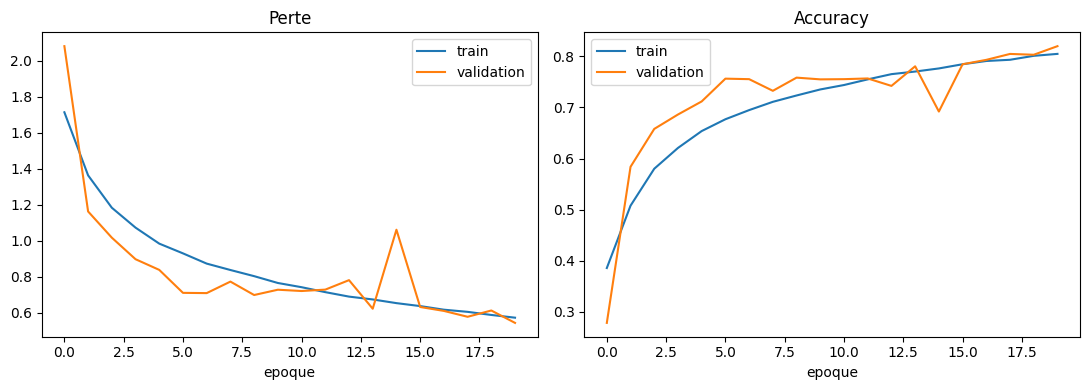

In [8]:
# Courbes d'apprentissage
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Perte'); plt.xlabel('epoque'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy'); plt.xlabel('epoque'); plt.legend()
plt.tight_layout(); plt.show()

## 6. Évaluer sur le jeu de test

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Accuracy sur le test : {test_acc:.4f}  (perte : {test_loss:.4f})')

Accuracy sur le test : 0.8084  (perte : 0.5888)


## 7. Analyser : matrice de confusion et erreurs

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


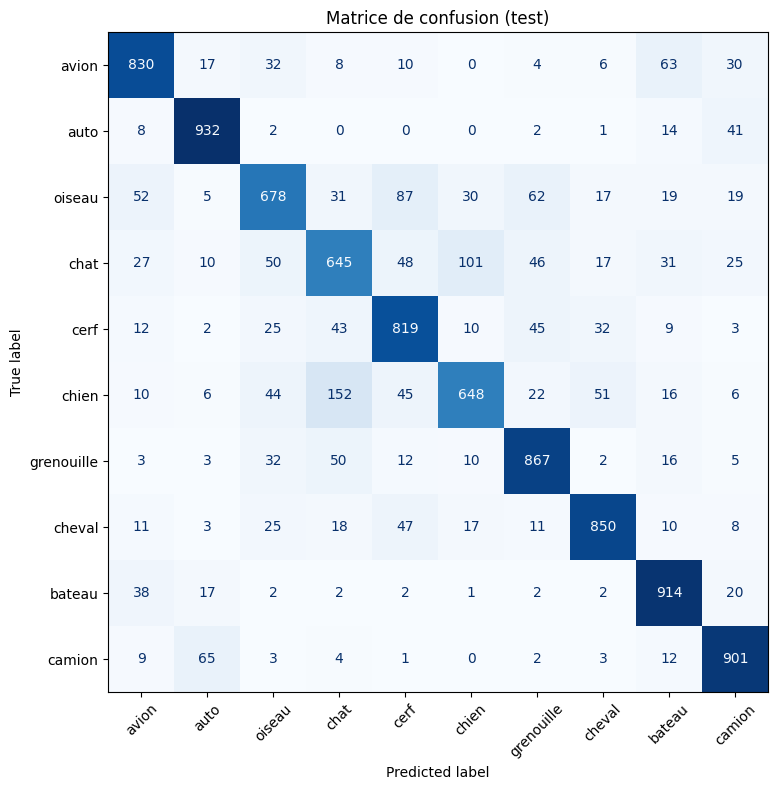

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
plt.title('Matrice de confusion (test)')
plt.tight_layout(); plt.show()

Nombre d'erreurs : 1916 sur 10000


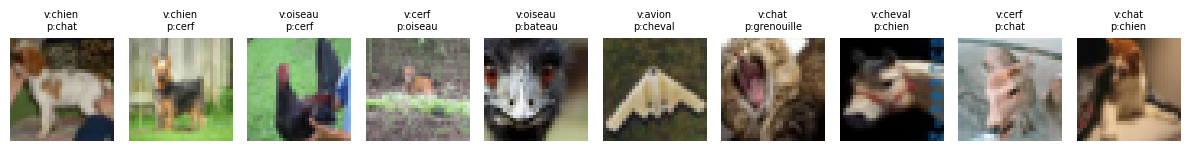

In [11]:
# Quelques erreurs du modele
errors = np.where(y_pred != y_test)[0]
print('Nombre d\'erreurs :', len(errors), 'sur', len(y_test))

plt.figure(figsize=(12, 2))
for i, idx in enumerate(errors[:10]):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f'v:{class_names[y_test[idx]]}\np:{class_names[y_pred[idx]]}', fontsize=7)
    plt.axis('off')
plt.tight_layout(); plt.show()

## 8. À toi de jouer

Améliore le CNN et observe l'effet sur l'accuracy de test :
1. **Plus de profondeur** : ajoute un 3e bloc convolutif (`Conv128 -> Conv128 -> MaxPool`).
2. **Plus d'augmentation** : ajoute `rotation_range=15` ou `zoom_range=0.1` au générateur.
3. **Régularisation** : fais varier le `Dropout` (0.3, 0.5) ; observe l'écart train/val.
4. **Question** : quelles classes se confondent le plus dans la matrice (chat ↔ chien ?) ?
5. **Comparaison** : remplace tout le CNN par un réseau **dense** (Flatten -> Dense...) : combien d'accuracy perds-tu ?

> Note tes résultats dans un petit tableau (config → accuracy test).

In [12]:
# Ton espace d'experimentation
# ...